# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Risma Amaliyah Mahmudah
- **Email:** rismaamaliyah2@gmail.com
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install kaggle
!pip install scikit-image
!pip install split-folders

In [2]:
# Libraries mostly used
import numpy as np
import pandas as pd
import splitfolders
import warnings
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Libraries for images processing
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [4]:
# Libraries for model building
import keras
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [5]:
# Deactivate warning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
# Show TensorFlow version
print(tf.__version__)

2.19.0


## Data Preparation

### Data Loading

In [7]:
files.upload()

!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [8]:
!kaggle datasets download -d rushilprajapati/data-final -p ./dataset
!unzip -q dataset/data-final.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/rushilprajapati/data-final
License(s): apache-2.0
100% 2.32G/2.32G [00:24<00:00, 103MB/s]



### Data Preprocessing

#### Split Dataset

In [9]:
# Split dataset into 70% train, 20% val, 10% test
splitfolders.ratio("./dataset/data", output="./dataset_split", seed=1331, ratio=(0.7, 0.2, 0.1))

Copying files: 19105 files [00:15, 1223.72 files/s]


In [10]:
datagen = ImageDataGenerator(rescale=1./255)

train_ds = datagen.flow_from_directory(
    "./dataset_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_ds = datagen.flow_from_directory(
    "./dataset_split/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_ds = datagen.flow_from_directory(
    "./dataset_split/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 13372 images belonging to 6 classes.
Found 3819 images belonging to 6 classes.
Found 1914 images belonging to 6 classes.


## Modelling

In [11]:
# Initialize sequential model
model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary of the Model Architecture
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,269,318 (50.62 MB)

 Trainable params: 13,268,358 (50.61 MB)

 Non-trainable params: 960 (3.75 KB)

None


In [12]:
y_train = train_ds.classes

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights_dict # Corrected from class_weights to class_weight
)

Class Weights: {0: np.float64(1.698678861788618), 1: np.float64(2.975522919448153), 2: np.float64(0.6148045977011495), 3: np.float64(0.7136300565695378), 4: np.float64(2.110479797979798), 5: np.float64(0.6354909229160726)}
Epoch 1/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6388 - loss: 10.5817

418/418 ━━━━━━━━━━━━━━━━━━━━ 108s 227ms/step - accuracy: 0.6825 - loss: 6.8920 - val_accuracy: 0.3493 - val_loss: 13.4377
Epoch 2/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7071 - loss: 1.5907

418/418 ━━━━━━━━━━━━━━━━━━━━ 80s 191ms/step - accuracy: 0.7218 - loss: 1.3513 - val_accuracy: 0.8578 - val_loss: 0.5998
Epoch 3/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 79s 189ms/step - accuracy: 0.7438 - loss: 1.0743 - val_accuracy: 0.8534 - val_loss: 0.6039
Epoch 4/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7750 - loss: 0.8634

418/418 ━━━━━━━━━━━━━━━━━━━━ 80s 192ms/step - accuracy: 0.7836 - loss: 0.8319 - val_accuracy: 0.8217 - val_loss: 0.5468
Epoch 5/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 79s 189ms/step - accuracy: 0.8170 - loss: 0.7332 - val_accuracy: 0.7848 - val_loss: 0.7346
Epoch 6/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 85s 203ms/step - accuracy: 0.7948 - loss: 0.8269 - val_accuracy: 0.4721 - val_loss: 1.4297
Epoch 7/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 86s 205ms/step - accuracy: 0.8000 - loss: 0.7219 - val_accuracy: 0.5920 - val_loss: 1.6297
Epoch 8/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 86s 206ms/step - accuracy: 0.8406 - loss: 0.5531 - val_accuracy: 0.6517 - val_loss: 2.6978
Epoch 9/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 83s 199ms/step - accuracy: 0.8484 - loss: 0.5006 - val_accuracy: 0.6921 - val_loss: 0.9221
Epoch 10/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 85s 204ms/step - accuracy: 0.8666 - loss: 0.4455 - val_accuracy: 0.6481 - val_loss: 1.2546
Epoch 11/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8749 - loss: 0.4075

418/418 ━━━━━━━━━━━━━━━━━━━━ 84s 202ms/step - accuracy: 0.8833 - loss: 0.3894 - val_accuracy: 0.9175 - val_loss: 0.2589
Epoch 12/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 84s 200ms/step - accuracy: 0.8775 - loss: 0.4246 - val_accuracy: 0.8788 - val_loss: 0.3511
Epoch 13/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8857 - loss: 0.3994

418/418 ━━━━━━━━━━━━━━━━━━━━ 84s 202ms/step - accuracy: 0.8845 - loss: 0.3960 - val_accuracy: 0.9306 - val_loss: 0.2464
Epoch 14/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 83s 197ms/step - accuracy: 0.8921 - loss: 0.3750 - val_accuracy: 0.6625 - val_loss: 2.4740
Epoch 15/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8882 - loss: 0.3791

418/418 ━━━━━━━━━━━━━━━━━━━━ 84s 202ms/step - accuracy: 0.8926 - loss: 0.3663 - val_accuracy: 0.9217 - val_loss: 0.2196
Epoch 16/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.8943 - loss: 0.3509

418/418 ━━━━━━━━━━━━━━━━━━━━ 83s 198ms/step - accuracy: 0.8955 - loss: 0.3394 - val_accuracy: 0.9429 - val_loss: 0.1781
Epoch 17/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 81s 194ms/step - accuracy: 0.8969 - loss: 0.3685 - val_accuracy: 0.8243 - val_loss: 0.4251
Epoch 18/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9012 - loss: 0.3463

418/418 ━━━━━━━━━━━━━━━━━━━━ 81s 193ms/step - accuracy: 0.9050 - loss: 0.3228 - val_accuracy: 0.9387 - val_loss: 0.1745
Epoch 19/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 80s 191ms/step - accuracy: 0.9079 - loss: 0.3137 - val_accuracy: 0.7656 - val_loss: 0.6953
Epoch 20/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 79s 190ms/step - accuracy: 0.9053 - loss: 0.3286 - val_accuracy: 0.6112 - val_loss: 1.1773


## Evaluasi dan Visualisasi

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print('Test accuracy:', test_acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9279 - loss: 0.2142
Test accuracy: 0.9278996586799622


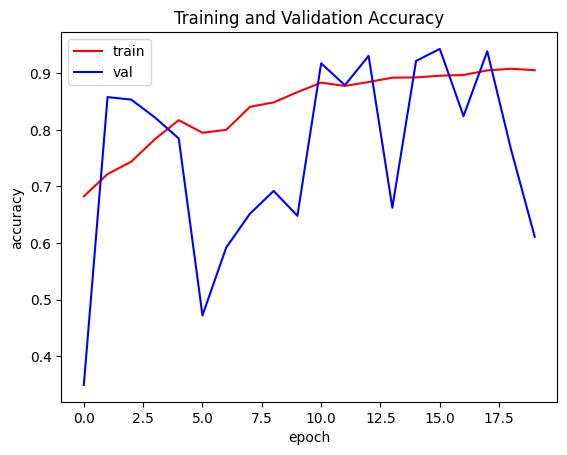

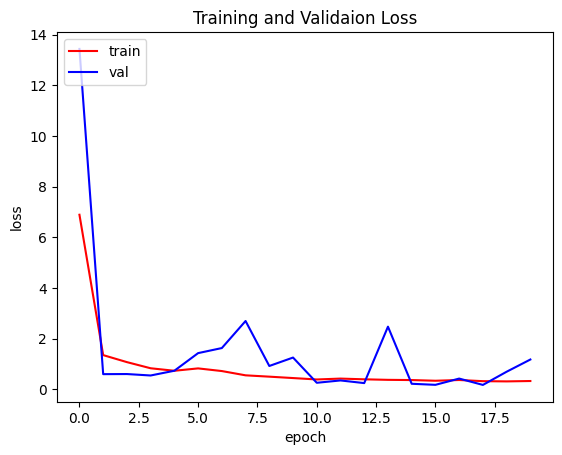

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step
                precision    recall  f1-score   support

      Blot-Gel       0.88      0.84      0.86       188
          FACS       0.96      1.00      0.98       107
Histopathology       0.96      0.99      0.97       519
    Macroscopy       1.00      0.84      0.91       447
    Microscopy       0.62      0.87      0.72       152
Non-scientific       0.99      0.97      0.98       501

      accuracy                           0.93      1914
     macro avg       0.90      0.92      0.91      1914
  weighted avg       0.94      0.93      0.93      1914



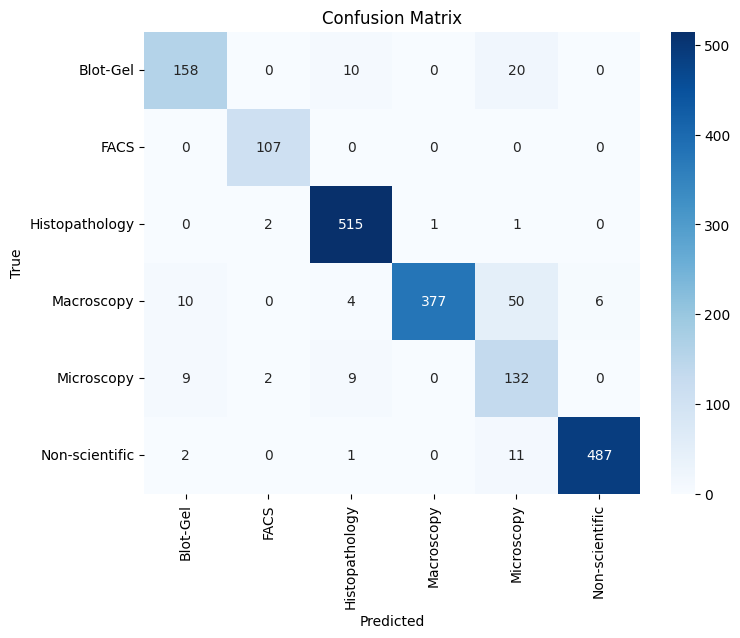

In [15]:
y_true = test_ds.classes

y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=test_ds.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_ds.class_indices.keys(), yticklabels=test_ds.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Konversi Model

In [23]:
model.export("saved_model/my_model")

Saved artifact at 'saved_model/my_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132081772649872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772650640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772652560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772652944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772649488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772652176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772651600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772651216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772653904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132081772654096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1320817726

In [25]:
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model/my_model")
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

labels = list(test_ds.class_indices.keys())
os.makedirs('tflite', exist_ok=True)
with open("tflite/label.txt", "w") as f:
    f.write("\n".join(labels))

In [26]:
!tensorflowjs_converter --input_format=tf_saved_model \
    --saved_model_tags=serve \
    saved_model/my_model \
    tfjs_model

2026-06-21 03:11:37.712272: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782011497.733445   12390 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782011497.740834   12390 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782011497.757195   12390 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782011497.757258   12390 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782011497.757264   12390 computation_placer.cc:177] computation placer alr

## Inference (Optional)

In [28]:
# Load model TF-Lite
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

img, label = test_ds[0][0][0], test_ds[0][1][0]
img = np.expand_dims(img, axis=0).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], img)
interpreter.invoke()
prediction = interpreter.get_tensor(output_details[0]['index'])

print("True label:", label)
print("Predicted:", np.argmax(prediction))

True label: [1. 0. 0. 0. 0. 0.]
Predicted: 4
